In [853]:
import pandas as pd 
import numpy as np 

In [854]:
car = pd.read_csv("/Users/ritikmishra/Desktop/ML_projects/car_price_prediction/data/CAR DETAILS FROM CAR DEKHO.csv")

In [855]:
car.shape

(4340, 8)

In [856]:
car.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,2016,550000,25000,Petrol,Individual,Manual,First Owner
7,Tata Indigo Grand Petrol,2014,240000,60000,Petrol,Individual,Manual,Second Owner
8,Hyundai Creta 1.6 VTVT S,2015,850000,25000,Petrol,Individual,Manual,First Owner
9,Maruti Celerio Green VXI,2017,365000,78000,CNG,Individual,Manual,First Owner


In [857]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [858]:
car.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [859]:
car.duplicated().sum()

np.int64(763)

In [860]:
car.drop_duplicates(inplace=True)

In [861]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3577 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           3577 non-null   object
 1   year           3577 non-null   int64 
 2   selling_price  3577 non-null   int64 
 3   km_driven      3577 non-null   int64 
 4   fuel           3577 non-null   object
 5   seller_type    3577 non-null   object
 6   transmission   3577 non-null   object
 7   owner          3577 non-null   object
dtypes: int64(3), object(5)
memory usage: 251.5+ KB


In [862]:
car['car_age'] = 2024 - car['year']

In [863]:
car.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,17
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,17
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,12
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,7
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,10


In [864]:
car['model'] = car['name'].str.split().str[:2].str.join(' ')

In [865]:
car['km_per_year'] = car['km_driven'] / (car['car_age']+1)

# EDA

In [866]:
car.describe()

,year,selling_price,km_driven,car_age,km_per_year
count,3577.000000,3.577000e+03,3577.000000,3577.000000,3577.000000
mean,2012.962538,4.739125e+05,69250.545709,11.037462,5724.374209
std,4.251759,5.093018e+05,47579.940016,4.251759,3613.098246
min,1992.000000,2.000000e+04,1.000000,4.000000,0.090909
25%,2010.000000,2.000000e+05,36000.000000,8.000000,3333.333333
50%,2013.000000,3.500000e+05,60000.000000,11.000000,5138.200000
75%,2016.000000,6.000000e+05,90000.000000,14.000000,7272.727273
max,2020.000000,8.900000e+06,806599.000000,32.000000,62222.222222


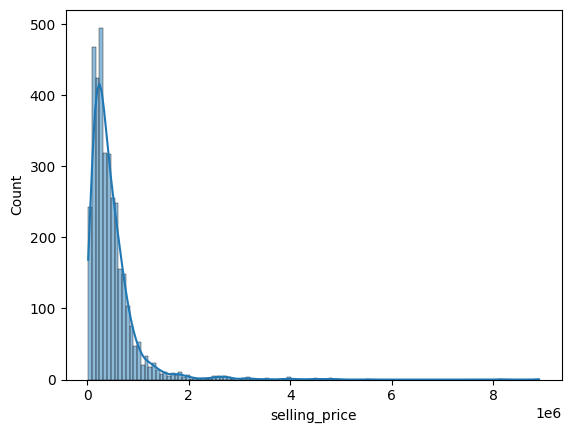

In [867]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(car['selling_price'], kde=True)
plt.show()

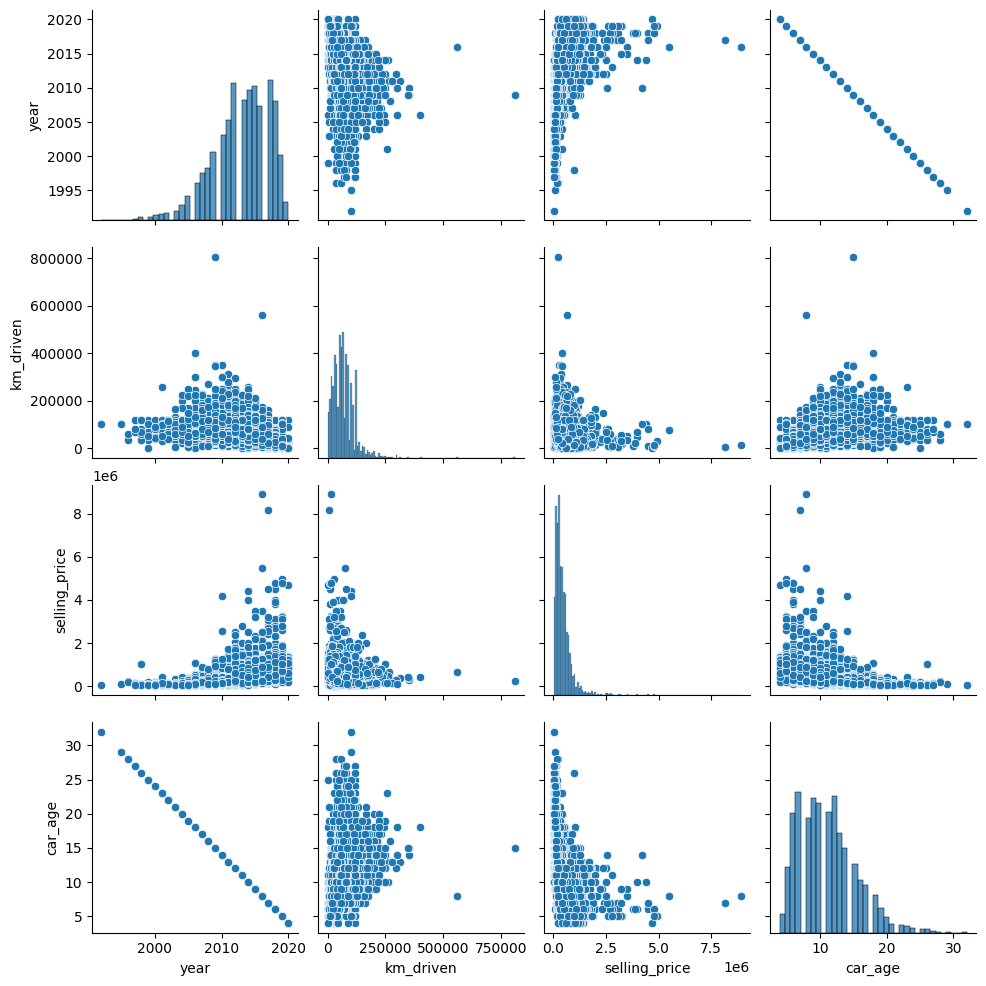

In [868]:
sns.pairplot(car[['year','km_driven','selling_price','car_age']])
plt.show()

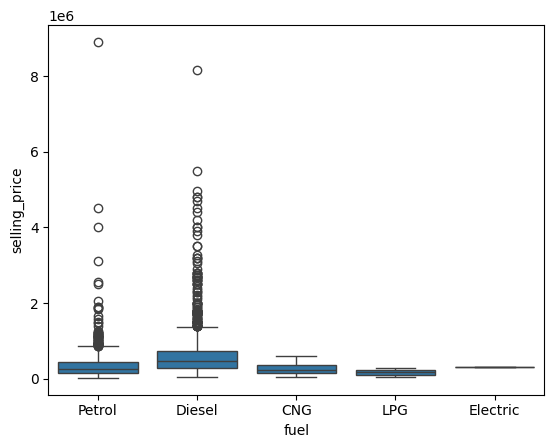

In [869]:
sns.boxplot(x=car['fuel'], y=car['selling_price'])
plt.show()

diesel cars are more expensive than any other cars and their are outliers because of luxury cars segment 

In [870]:
# q1 = car['selling_price'].quantile(0.25)
# q3 = car['selling_price'].quantile(0.75)

# IQR = q3-q1

# lower = q1 - 1.5*IQR
# upper = q3 + 1.5*IQR

In [871]:
#car = car[(car['selling_price']>=lower)& (car['selling_price']<=upper)]

<function matplotlib.pyplot.show(close=None, block=None)>

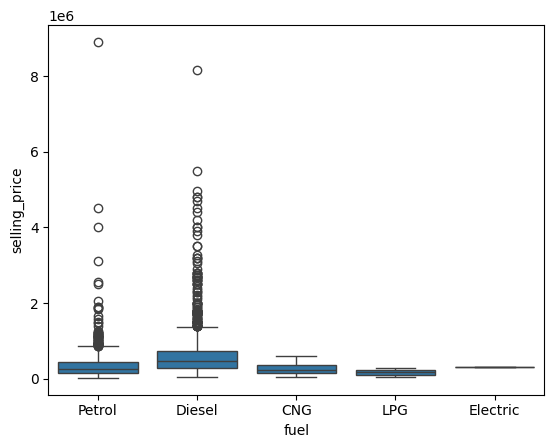

In [872]:
sns.boxplot(x=car['fuel'],y=car['selling_price'])
plt.show

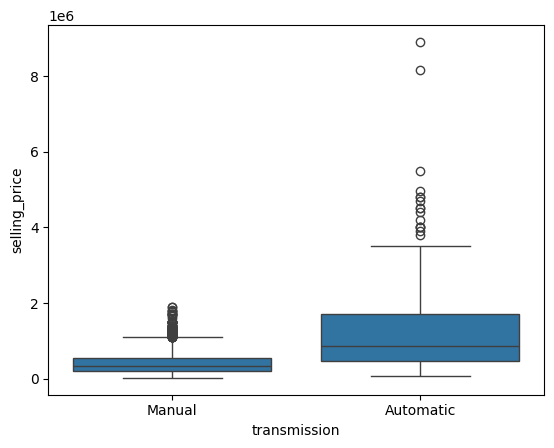

In [873]:
sns.boxplot(x=car['transmission'], y=car['selling_price'])
plt.show()

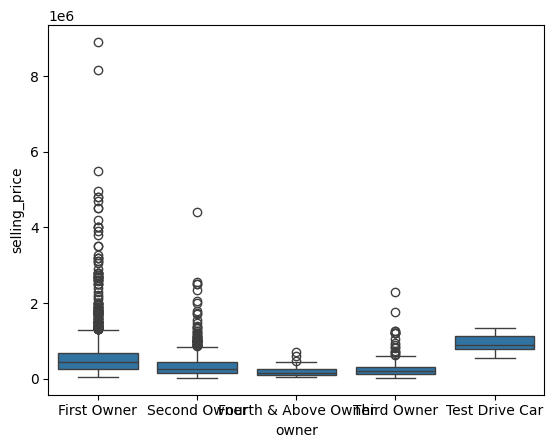

In [874]:
sns.boxplot(x=car['owner'], y=car['selling_price'])
plt.show()

In [875]:
# owner_map = {
#     "First Owner": 1,
#     "Second Owner": 2,
#     "Third Owner": 3,
#     "Fourth & Above Owner": 4,
#     "Test Drive Car": 0
# }

# car['owner'] = car['owner'].map(owner_map)

In [876]:
# selling price is right skewed 
car['selling_price'] = np.log(car['selling_price'])

In [877]:
car.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,model,km_per_year
0,Maruti 800 AC,2007,11.002100,70000,Petrol,Individual,Manual,First Owner,17,Maruti 800,3888.888889
1,Maruti Wagon R LXI Minor,2007,11.813030,50000,Petrol,Individual,Manual,First Owner,17,Maruti Wagon,2777.777778
2,Hyundai Verna 1.6 SX,2012,13.304685,100000,Diesel,Individual,Manual,First Owner,12,Hyundai Verna,7692.307692
3,Datsun RediGO T Option,2017,12.429216,46000,Petrol,Individual,Manual,First Owner,7,Datsun RediGO,5750.000000
4,Honda Amaze VX i-DTEC,2014,13.017003,141000,Diesel,Individual,Manual,Second Owner,10,Honda Amaze,12818.181818


In [878]:
car.drop(columns=['year'],inplace=True)

In [879]:
car.shape

(3577, 10)

In [880]:
car['brand'] = car['name'].str.split().str.get(0)

In [881]:
car.drop(columns=['name'],inplace=True)

In [882]:
car.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,model,km_per_year,brand
0,11.002100,70000,Petrol,Individual,Manual,First Owner,17,Maruti 800,3888.888889,Maruti
1,11.813030,50000,Petrol,Individual,Manual,First Owner,17,Maruti Wagon,2777.777778,Maruti
2,13.304685,100000,Diesel,Individual,Manual,First Owner,12,Hyundai Verna,7692.307692,Hyundai
3,12.429216,46000,Petrol,Individual,Manual,First Owner,7,Datsun RediGO,5750.000000,Datsun
4,13.017003,141000,Diesel,Individual,Manual,Second Owner,10,Honda Amaze,12818.181818,Honda


# Model

In [883]:
X = car.drop(columns=['selling_price'])
y = car['selling_price']

In [884]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# numerical
- km_driven
- car_age
# categorical
- brand
- fuel
- seller type 
- transmission 
- owners

In [885]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [886]:
categorical_cols = ['brand','fuel','seller_type','transmission','owner']
numerical_cols = ['km_driven','car_age','km_per_year']

preprocessor = ColumnTransformer(
    transformers = [
        ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_cols),
        ('num', 'passthrough', numerical_cols)
                    ]
)

In [887]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [888]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBRegressor(n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42))
])

In [889]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [890]:
y_pred = pipe.predict(X_test)

In [893]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.7930491224472933
MAE: 0.289731448547065


In [894]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')

print(scores)
print("Average R2:", scores.mean())

[0.79696878 0.79527738 0.77546221 0.75528011 0.76288752]
Average R2: 0.7771751997236068


In [895]:
comparison = pd.DataFrame({
    "Actual Price": np.exp(y_test),
    "Predicted Price": np.exp(y_pred)
}).astype(int)
comparison

,Actual Price,Predicted Price
1045,269999,478501
3194,524999,459593
1530,989999,1272670
553,3800000,2440201
1612,229998,214060
...,...,...
384,249999,183479
3529,469999,556373
673,137999,202060
2556,114999,319903


In [897]:
print(pipe.score(X_train, y_train))
print(pipe.score(X_test, y_test))

0.9246338396831514
0.7930491224472933


In [898]:
import pickle

pickle.dump(pipe,open("car_price_model.pkl", "wb"))